In [1]:
import jax
from jax import numpy as jnp
from jax import jit

In [2]:
class Node:
  def __init__(self,x,y):
    self.params = {'b' : jnp.float32(0),
    'w' : jnp.zeros(x.shape[1])}

  @staticmethod
  @jit
  def loss(params,x,y):
    pred = Node.predict(params,x)
    mse = jnp.mean((pred - y)**2)
    return mse

  @staticmethod
  @jit
  def predict(params,x):
    pred = jnp.dot(x,params['w']) + params['b']
    return pred

  @staticmethod
  @jit
  def grad(params,x,y):
    return jax.grad(Node.loss)(params,x,y)

  @staticmethod
  @jit
  def grad_step(x,y,params):
    param_grad = Node.grad(params,x,y)
    param_grad['w'] = params['w'] -0.01*param_grad['w']
    param_grad['b'] = params['b'] - 0.01*param_grad['b']
    return param_grad

  def fit(self,x,y,epochs = 100):
    for i in range(epochs):
      self.params = Node.grad_step(x,y,self.params)
      print(f"Epoch {i + 1} | Loss : {Node.loss(self.params,x,y)}")






In [3]:
a = jnp.array([[2,4],[5,4]])
b = jnp.array([[6,9]])

In [4]:
x = Node(a,b)

In [5]:
x.fit(a,b, epochs = 20)

Epoch 1 | Loss : 9.148049354553223
Epoch 2 | Loss : 1.4358071088790894
Epoch 3 | Loss : 0.23034889996051788
Epoch 4 | Loss : 0.041680943220853806
Epoch 5 | Loss : 0.011914743110537529
Epoch 6 | Loss : 0.006993578746914864
Epoch 7 | Loss : 0.0059681483544409275
Epoch 8 | Loss : 0.005564300809055567
Epoch 9 | Loss : 0.005269795656204224
Epoch 10 | Loss : 0.005003854166716337
Epoch 11 | Loss : 0.004753502551466227
Epoch 12 | Loss : 0.004515951033681631
Epoch 13 | Loss : 0.004290272481739521
Epoch 14 | Loss : 0.004075893200933933
Epoch 15 | Loss : 0.0038722814060747623
Epoch 16 | Loss : 0.0036787951830774546
Epoch 17 | Loss : 0.003495012642815709
Epoch 18 | Loss : 0.0033204122446477413
Epoch 19 | Loss : 0.003154528560116887
Epoch 20 | Loss : 0.002996898489072919


Array([6.063899, 8.956288], dtype=float32)

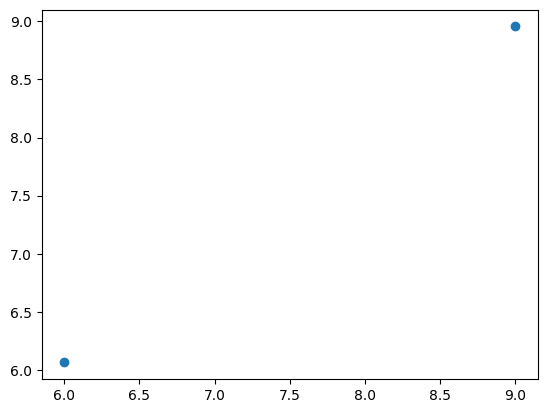

In [6]:
import matplotlib.pyplot as plt
import numpy as np
plt.scatter(b,x.predict(x.params,a))
x.predict(x.params,a)

In [ ]:
import sys
sys.getsizeof(Node)

1704